In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
# Load dataset
df = pd.read_csv("C:/Users/skhar/OneDrive/Desktop/Enhanced_Smart_Accident_Dataset.csv")

df.head()

,accident_id,latitude,longitude,state,zone_name,hour,Unnamed: 6,light_condition,speed_limit,vehicles_involved,...,Date,Time,Speed_Limit,Road_Type,Traffic_Density_Index,Visibility_Score,Road_Curvature,Lighting_Condition,Rain_Intensity,Ambulance_Response_Time
0,a000001,13.049344,80.280267,tamil nadu,chennai,6,NaN,daylight,80,2,...,19-08-2016,Morning,60,Urban,5,7,Sharp,Night,2,19
1,a000002,26.860652,75.770431,rajasthan,jaipur,17,NaN,daylight,60,3,...,07-07-2017,Evening,100,Highway,10,3,Sharp,Night,3,17
2,a000003,22.554581,88.355149,west bengal,kolkata,18,NaN,darkness - lights lit,80,1,...,23-04-2017,Night,80,Urban,10,10,Low,Day,9,25
3,a000004,11.038954,76.960941,tamil nadu,coimbatore,4,NaN,darkness - lights lit,120,2,...,24-08-2017,Morning,60,Urban,1,7,Low,Day,6,16
4,a000005,28.078364,73.762755,various,rural area,0,NaN,darkness - lights lit,30,2,...,06-07-2023,Evening,40,Rural,8,10,Low,Night,9,14


In [4]:
df.isnull().sum()

accident_id                    0
latitude                       0
longitude                      0
state                          0
zone_name                      0
hour                           0
Unnamed: 6                 20400
light_condition                0
speed_limit                    0
vehicles_involved              0
injuries_count                 0
fatalities_count               0
accident_severity              0
random_noise_column            0
weather_dust                   0
weather_fog                    0
weather_hail                   0
weather_overcast               0
weather_rain                   0
traffic_density_low            0
traffic_density_medium         0
road_type_rural road           0
road_type_state highway        0
road_type_urban road           0
cluster                        0
dbscan_cluster                 0
level                          0
Date                           0
Time                           0
Speed_Limit                    0
Road_Type 

In [5]:
import numpy as np

def severity_to_range(value):
    if value == "Low":
        return np.random.uniform(0, 0.3)
    elif value == "Medium":
        return np.random.uniform(0.3, 0.6)
    elif value == "High":
        return np.random.uniform(0.6, 1)

df["risk_score"] = df["level"].apply(severity_to_range)

In [6]:
df['risk_score'].value_counts()

risk_score
0.181352    1
0.853537    1
0.862680    1
0.045922    1
0.576757    1
           ..
0.115371    1
0.347192    1
0.354391    1
0.126863    1
0.987183    1
Name: count, Length: 20400, dtype: int64

In [7]:
df = df.drop(columns=[
    'Unnamed: 6',
    'random_noise_column'
])

In [8]:
df = df.drop(columns=['speed_limit'])

In [9]:
curvature_map = {
    'Low': 0.2,
    'Moderate': 0.6,
    'Sharp': 0.9
}

df['Road_Curvature'] = df['Road_Curvature'].map(curvature_map)

In [10]:
df["Road_Curvature"]

0        0.9
1        0.9
2        0.2
3        0.2
4        0.2
        ... 
20395    0.9
20396    0.9
20397    0.2
20398    0.2
20399    0.2
Name: Road_Curvature, Length: 20400, dtype: float64

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = [
    'Speed_Limit',
    'Traffic_Density_Index',
    'Visibility_Score',
    'Road_Curvature',
    'Rain_Intensity',
    'Ambulance_Response_Time',
    'vehicles_involved',
    'injuries_count',
    'fatalities_count'
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [12]:
df['Risk_Score'] = (
    0.20 * df['Speed_Limit'] +
    0.15 * df['Traffic_Density_Index'] +
    0.15 * (1 - df['Visibility_Score'])  +
    0.10 * df['Rain_Intensity'] +
    0.10 * df['vehicles_involved'] +
    0.10 * df['injuries_count'] +
    0.10 * df['fatalities_count']
)

In [13]:
df['Risk_Score']

0        0.260696
1        0.577692
2        0.396410
3        0.267363
4        0.226667
           ...   
20395    0.341026
20396    0.335385
20397    0.246813
20398    0.501245
20399    0.257692
Name: Risk_Score, Length: 20400, dtype: float64

In [14]:
def categorize_risk(score):
    if score <= 0.3:
        return "Low"
    elif score <= 0.6:
        return "Medium"
    elif score <= 0.8:
        return "High"
    else:
        return "Critical"

df['Risk_Level'] = df['Risk_Score'].apply(categorize_risk)

In [15]:
df['Risk_Level'].value_counts()

Risk_Level
Medium    11532
Low        8797
High         71
Name: count, dtype: int64

In [16]:
df_model = df.drop(columns=[
    'accident_id',
    'cluster',
    'dbscan_cluster',
    'Date',
    'Time'
])

In [17]:
df_model= df.drop(columns='Road_Curvature')

In [18]:
X = df_model.drop(columns=['Risk_Level'])
y = df_model['Risk_Level']

In [19]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64','bool']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['accident_id', 'state', 'zone_name', 'light_condition',
       'accident_severity', 'level', 'Date', 'Time', 'Road_Type',
       'Lighting_Condition'],
      dtype='object')
Numerical: Index(['latitude', 'longitude', 'hour', 'vehicles_involved', 'injuries_count',
       'fatalities_count', 'weather_dust', 'weather_fog', 'weather_hail',
       'weather_overcast', 'weather_rain', 'traffic_density_low',
       'traffic_density_medium', 'road_type_rural road',
       'road_type_state highway', 'road_type_urban road', 'cluster',
       'dbscan_cluster', 'Speed_Limit', 'Traffic_Density_Index',
       'Visibility_Score', 'Rain_Intensity', 'Ambulance_Response_Time',
       'risk_score', 'Risk_Score'],
      dtype='object')


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight='balanced',
        random_state=42
    ))
])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [22]:
df_model.isnull().sum().sort_values(ascending=False)

accident_id                0
latitude                   0
longitude                  0
state                      0
zone_name                  0
hour                       0
light_condition            0
vehicles_involved          0
injuries_count             0
fatalities_count           0
accident_severity          0
weather_dust               0
weather_fog                0
weather_hail               0
weather_overcast           0
weather_rain               0
traffic_density_low        0
traffic_density_medium     0
road_type_rural road       0
road_type_state highway    0
road_type_urban road       0
cluster                    0
dbscan_cluster             0
level                      0
Date                       0
Time                       0
Speed_Limit                0
Road_Type                  0
Traffic_Density_Index      0
Visibility_Score           0
Lighting_Condition         0
Rain_Intensity             0
Ambulance_Response_Time    0
risk_score                 0
Risk_Score    

In [23]:
df.isnull().sum().sort_values(ascending=False)

accident_id                0
latitude                   0
longitude                  0
state                      0
zone_name                  0
hour                       0
light_condition            0
vehicles_involved          0
injuries_count             0
fatalities_count           0
accident_severity          0
weather_dust               0
weather_fog                0
weather_hail               0
weather_overcast           0
weather_rain               0
traffic_density_low        0
traffic_density_medium     0
road_type_rural road       0
road_type_state highway    0
road_type_urban road       0
cluster                    0
dbscan_cluster             0
level                      0
Date                       0
Time                       0
Speed_Limit                0
Road_Type                  0
Traffic_Density_Index      0
Visibility_Score           0
Road_Curvature             0
Lighting_Condition         0
Rain_Intensity             0
Ambulance_Response_Time    0
risk_score    

In [24]:
X = df_model.drop(columns=['Risk_Level'])
y = df_model['Risk_Level']

In [25]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64','bool']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['accident_id', 'state', 'zone_name', 'light_condition',
       'accident_severity', 'level', 'Date', 'Time', 'Road_Type',
       'Lighting_Condition'],
      dtype='object')
Numerical: Index(['latitude', 'longitude', 'hour', 'vehicles_involved', 'injuries_count',
       'fatalities_count', 'weather_dust', 'weather_fog', 'weather_hail',
       'weather_overcast', 'weather_rain', 'traffic_density_low',
       'traffic_density_medium', 'road_type_rural road',
       'road_type_state highway', 'road_type_urban road', 'cluster',
       'dbscan_cluster', 'Speed_Limit', 'Traffic_Density_Index',
       'Visibility_Score', 'Rain_Intensity', 'Ambulance_Response_Time',
       'risk_score', 'Risk_Score'],
      dtype='object')


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight='balanced',
        random_state=42
    ))
])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [28]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['latitude', 'longitude', 'hour', 'vehicles_involved', 'injuries_count',
       'fatalities_count', 'weather_dust', 'weather_fog', 'weather_hail',
       'weather_overcast', 'weather_rain', 'traffic_density_low',
       'traffic_density_medium', 'road_type_rural road',
       'road_type_state highwa...
       'risk_score', 'Risk_Score'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['accident_id', 'state', 'zone_name', 'light_condition',
       'accident_severity', 'level', 'Date', 'Time', 'Road_Type',
       'Lighting_Condition'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        n_estimators=300, random_state=42))])

              precision    recall  f1-score   support

        High       0.82      0.64      0.72        14
         Low       0.90      1.00      0.95      1760
      Medium       1.00      0.92      0.96      2306

    accuracy                           0.95      4080
   macro avg       0.91      0.85      0.87      4080
weighted avg       0.96      0.95      0.95      4080



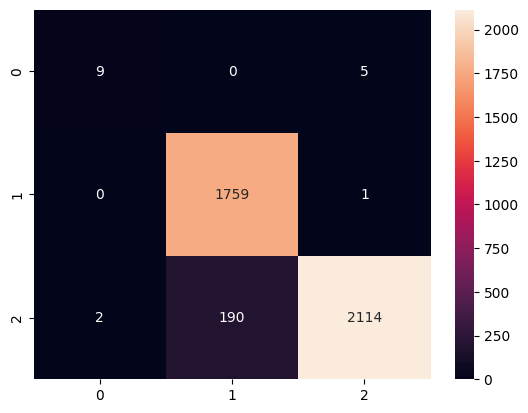

In [29]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [30]:
df['Risk_Score'].describe()

count    2.040000e+04
mean     3.205905e-01
std      1.037493e-01
min      3.330669e-17
25%      2.471429e-01
50%      3.181136e-01
75%      3.910256e-01
max      6.774359e-01
Name: Risk_Score, dtype: float64

In [31]:
df['Risk_Level'].value_counts()

Risk_Level
Medium    11532
Low        8797
High         71
Name: count, dtype: int64

In [32]:
df

,accident_id,latitude,longitude,state,zone_name,hour,light_condition,vehicles_involved,injuries_count,fatalities_count,...,Road_Type,Traffic_Density_Index,Visibility_Score,Road_Curvature,Lighting_Condition,Rain_Intensity,Ambulance_Response_Time,risk_score,Risk_Score,Risk_Level
0,a000001,13.049344,80.280267,tamil nadu,chennai,6,daylight,0.2,0.230769,0.000000,...,Urban,0.444444,0.571429,1.0,Night,0.2,0.647059,0.181352,0.260696,Low
1,a000002,26.860652,75.770431,rajasthan,jaipur,17,daylight,0.4,0.076923,0.000000,...,Highway,1.000000,0.000000,1.0,Night,0.3,0.529412,0.853537,0.577692,Medium
2,a000003,22.554581,88.355149,west bengal,kolkata,18,darkness - lights lit,0.0,0.230769,0.000000,...,Urban,1.000000,1.000000,0.0,Day,0.9,1.000000,0.862680,0.396410,Medium
3,a000004,11.038954,76.960941,tamil nadu,coimbatore,4,darkness - lights lit,0.2,0.230769,0.333333,...,Urban,0.000000,0.571429,0.0,Day,0.6,0.470588,0.045922,0.267363,Low
4,a000005,28.078364,73.762755,various,rural area,0,darkness - lights lit,0.2,0.000000,0.000000,...,Rural,0.777778,1.000000,0.0,Night,0.9,0.352941,0.576757,0.226667,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,a014901,12.979853,77.578270,karnataka,bengaluru,17,daylight,0.2,0.076923,0.000000,...,Urban,0.111111,0.000000,1.0,Night,0.8,0.058824,0.115371,0.341026,Medium
20396,a011227,23.901244,76.403870,karnataka,ludhiana-bengaluru corridor,20,darkness - lights lit,0.4,0.153846,0.000000,...,Rural,0.666667,0.000000,1.0,Night,0.3,0.176471,0.347192,0.335385,Medium
20397,a019133,22.294398,73.186184,gujarat,vadodara,9,daylight,0.4,0.153846,0.000000,...,Urban,0.222222,0.857143,0.0,Night,0.7,0.294118,0.354391,0.246813,Low
20398,a007921,12.960057,77.611138,karnataka,bengaluru,11,daylight,0.4,0.307692,0.000000,...,Urban,0.666667,0.285714,0.0,Day,0.9,0.176471,0.126863,0.501245,Medium


In [33]:
df['Risk_Score'].describe()

count    2.040000e+04
mean     3.205905e-01
std      1.037493e-01
min      3.330669e-17
25%      2.471429e-01
50%      3.181136e-01
75%      3.910256e-01
max      6.774359e-01
Name: Risk_Score, dtype: float64

In [34]:
df['Risk_Level'] = pd.qcut(
    df['Risk_Score'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Critical']
)

In [35]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

        High       0.82      0.64      0.72        14
         Low       0.90      1.00      0.95      1760
      Medium       1.00      0.92      0.96      2306

    accuracy                           0.95      4080
   macro avg       0.91      0.85      0.87      4080
weighted avg       0.96      0.95      0.95      4080



In [36]:
selected_features = [
    'weather_dust',
    'weather_fog',
    'weather_hail',
    'weather_overcast',
    'weather_rain',
    'Road_Type',
    'hour',
    'Traffic_Density_Index'
]

In [37]:
y = df['Risk_Level']
X = df[selected_features]

In [38]:
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['hour'].apply(categorize_time)

In [39]:
selected_features = [
    'weather_dust',
    'weather_fog',
    'weather_hail',
    'weather_overcast',
    'weather_rain',
    'Road_Type',
    'Time_of_Day',
    'Traffic_Density_Index'
]

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

X = df[selected_features]
y = df['Risk_Level']

categorical_cols = ['Road_Type', 'Time_of_Day']
numerical_cols = ['Traffic_Density_Index']

boolean_cols = [
    'weather_dust',
    'weather_fog',
    'weather_hail',
    'weather_overcast',
    'weather_rain'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols + boolean_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight='balanced',
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Road_Type', 'Time_of_Day']),
                                                 ('num', 'passthrough',
                                                  ['Traffic_Density_Index',
                                                   'weather_dust',
                                                   'weather_fog',
                                                   'weather_hail',
                                                   'weather_overcast',
                                                   'weather_rain'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=300, random_state=42))])

In [41]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Critical       0.60      0.70      0.65      1020
        High       0.37      0.32      0.34      1020
         Low       0.56      0.68      0.61      1020
      Medium       0.35      0.26      0.29      1020

    accuracy                           0.49      4080
   macro avg       0.47      0.49      0.47      4080
weighted avg       0.47      0.49      0.47      4080



In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib

# Features
selected_features = [
    'weather_dust',
    'weather_fog',
    'weather_hail',
    'weather_overcast',
    'weather_rain',
    'Road_Type',
    'Time_of_Day',
    'Traffic_Density_Index'
]

X = df[selected_features]
y = df['Risk_Level']

categorical_cols = ['Road_Type', 'Time_of_Day']
numerical_cols = ['Traffic_Density_Index']
boolean_cols = [
    'weather_dust',
    'weather_fog',
    'weather_hail',
    'weather_overcast',
    'weather_rain'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols + boolean_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight='balanced',
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model.fit(X_train, y_train)

# Save model
joblib.dump(model, "C:/Users/skhar/OneDrive/Desktop/risk_prediction_model.pkl")

['C:/Users/skhar/OneDrive/Desktop/risk_prediction_model.pkl']

In [47]:
def predict_risk():
    
    # === USER INPUT ===
    weather = input("Enter weather (dust/fog/hail/overcast/rain/clear): ").lower()
    road_type = input("Enter road type (urban road/state highway/rural road): ")
    time_of_day = input("Enter time of day (Morning/Afternoon/Evening/Night): ")
    traffic_density = float(input("Enter traffic density index (0-10): "))
    
    
    # === Convert weather into boolean columns ===
    weather_cols = {
        "weather_dust": False,
        "weather_fog": False,
        "weather_hail": False,
        "weather_overcast": False,
        "weather_rain": False
    }
    
    if weather == "dust":
        weather_cols["weather_dust"] = True
    elif weather == "fog":
        weather_cols["weather_fog"] = True
    elif weather == "hail":
        weather_cols["weather_hail"] = True
    elif weather == "overcast":
        weather_cols["weather_overcast"] = True
    elif weather == "rain":
        weather_cols["weather_rain"] = True
    
    # === Create input dictionary ===
    input_dict = {
        **weather_cols,
        "Road_Type": road_type,
        "Time_of_Day": time_of_day,
        "Traffic_Density_Index": traffic_density
    }
    
    input_df = pd.DataFrame([input_dict])
    
    # === Predict ===
    prediction = model.predict(input_df)
    probabilities = model.predict_proba(input_df)
    
    print("\n✅ Predicted Risk Level:", prediction[0])
    print("\n📊 Risk Probabilities:")
    
    for label, prob in zip(model.classes_, probabilities[0]):
        print(f"{label}: {round(prob*100,2)}%")

In [45]:
predict_risk()

Enter weather (dust/fog/hail/overcast/rain/clear):  hfjyg
Enter road type (urban road/state highway/rural road):  jhgjh
Enter time of day (Morning/Afternoon/Evening/Night):  hfhgf
Enter traffic density index (0-10):  vhfhjg


ValueError: could not convert string to float: 'vhfhjg'